In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import matplotlib as mpl
import matplotlib.font_manager as font_manager
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import rcParams
import matplotlib.colors as mcolors
plt.rc('font',family='serif')
plt.rc('xtick',labelsize=18)
plt.rc('ytick',labelsize=18)
plt.rc('axes',labelsize=20)
plt.rc('axes',titlesize=20)
plt.rc('legend',fontsize=16)
plt.rc('lines', linewidth=2)
plt.rc('savefig', dpi=300)

plt.rcParams['figure.autolayout'] =  True
plt.rcParams["font.family"] = "Serif"
cmfont = font_manager.FontProperties(fname=mpl.get_data_path() + '/fonts/ttf/cmr10.ttf')
mpl.rcParams['font.serif']=cmfont.get_name()
mpl.rcParams['mathtext.fontset']='cm'
mpl.rcParams['axes.unicode_minus']=False
plt.rcParams['figure.figsize'] = [10, 8]
colors = list(mcolors.TABLEAU_COLORS.values())

In [3]:
from scipy.interpolate import UnivariateSpline

def bootstrap(u, ene, stoc_err, u_vals, n_iterations=10000, smoothing=0.0001):
    """Bootstrap resampling to estimate the mean and standard deviation."""
    ene_smooth = []
    for _ in range(n_iterations):
        ene_i = np.random.normal(ene, stoc_err)
        spline = UnivariateSpline(u, ene_i, s=smoothing, k=3)
        ene_i_smooth = spline(u_vals)
        ene_smooth.append(ene_i_smooth)
    ene_smooth = np.array(ene_smooth)
    # mean and standard deviation of the splines
    ene_mean = np.mean(ene_smooth, axis=0)
    ene_std = np.std(ene_smooth, axis=0)
    return ene_mean, ene_std

In [4]:
fci_data = np.array(
    [
        [4, -15.560423326606701],
        [5, -13.24217333535643],
        [6, -11.288779132385045],
        [7, -9.704893461753894],
        [8, -8.470543984513839],
        [9, -7.554142941759264],
        [10, -6.8395824683939646],
        [11, -6.259927135172623],
        [12, -5.777239091824939]
    ]
)
fci_data[:, 1] = fci_data[:, 1] / 16.0  

cpmc_fe_data = np.array(
    [
        [4, -15.582, 0.002],
        [5, -13.286, 0.002],
        [6, -11.353, 0.005],
        [7, -9.773, 0.007],
        [8, -8.549, 0.008],
        [9, -7.31, 0.01],
        [10, -6.53, 0.02],
        [11, -5.93, 0.01],
        [12, -5.43, 0.01],
    ]
)
cpmc_fe_data[:, 1] = cpmc_fe_data[:, 1] / 16.0  
cpmc_fe_data[:, 2] = cpmc_fe_data[:, 2] / 16.0  

cpmc_symm_data = np.array(
    [
        [4, -15.558, 0.001],
        [5, -13.232, 0.001],
        [6, -11.236, 0.002],
        [7, -9.624, 0.001],
        # [8, -8.359, 0.002],
        [8, -8.383, 0.002],
        [9, -7.498, 0.008],
        [10, -6.792, 0.001],
        [11, -6.209, 0.002],
        [12, -5.734, 0.003],
    ]
)
cpmc_symm_data[:, 1] = cpmc_symm_data[:, 1] / 16.0  
cpmc_symm_data[:, 2] = cpmc_symm_data[:, 2] / 16.0  

from scipy.interpolate import UnivariateSpline

fci_ene = UnivariateSpline(fci_data[:, 0], fci_data[:, 1], s=0.0, k=3)
u_vals = np.linspace(4, 12, 100)

cpmc_fe_b_mean, cpmc_fe_b_std = bootstrap(
    cpmc_fe_data[:, 0], cpmc_fe_data[:, 1], cpmc_fe_data[:, 2], u_vals
)

cpmc_symm_b_mean, cpmc_symm_b_std = bootstrap(
    cpmc_symm_data[:, 0],
    cpmc_symm_data[:, 1],
    cpmc_symm_data[:, 2],
    u_vals,
)

/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_22284/506998071.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize=(8, 7))
/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_22284/506998071.py:37: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax_inset = inset_axes(
/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_22284/506998071.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


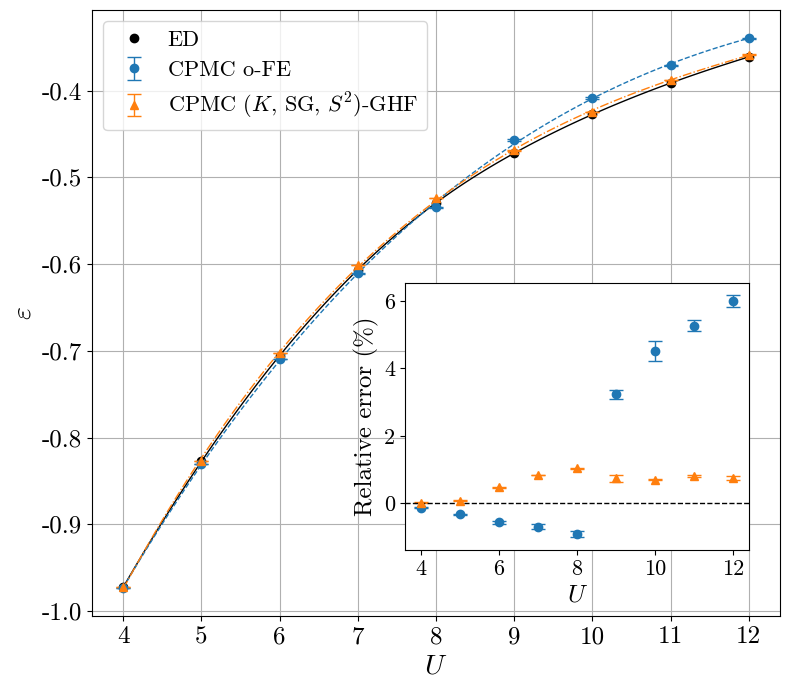

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(fci_data[:, 0], fci_data[:, 1], "o", label="ED", color='k')
ax.plot(u_vals, fci_ene(u_vals), "-", color="k", lw=1)

ax.errorbar(
    cpmc_fe_data[:, 0],
    cpmc_fe_data[:, 1],
    yerr=cpmc_fe_data[:, 2],
    fmt="o",
    color=colors[0],
    label="CPMC o-FE",
    capsize=5,
    lw=1
)
ax.plot(u_vals, cpmc_fe_b_mean, "--", lw=1, color=colors[0])

ax.errorbar(
    cpmc_symm_data[:, 0],
    cpmc_symm_data[:, 1],
    yerr=cpmc_symm_data[:, 2],
    fmt="^",
    color=colors[1],
    label=r"CPMC ($K$, SG, $S^2$)-GHF",
    capsize=5,
    lw=1
)
ax.plot(u_vals, cpmc_symm_b_mean, "-.", lw=1, color=colors[1],)

ax.grid()
ax.set_xlabel(r"$U$")
ax.set_ylabel(r"$\varepsilon$")
ax.legend(handletextpad=0.5)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

ax_inset = inset_axes(
    ax,
    width="50%",
    height="40%",
    # loc="lower right",
    bbox_to_anchor=(
        -0.045,
        -0.55,
        1.0,
        1.1,
    ),  
    bbox_transform=ax.transAxes,
    borderpad=0,
)

# dmrg_ene_at_cpmc_fe_u = np.array(dmrg_ene(cpmc_fe_data[:, 0]))
# error_fe = (cpmc_fe_data[:, 1] - dmrg_ene_at_cpmc_fe_u) / np.absolute(dmrg_ene_at_cpmc_fe_u) * 100.
# dmrg_ene_at_cpmc_symm_u = np.array(dmrg_ene(cpmc_symm_data[:, 0]))
# error_symm = (cpmc_symm_data[:, 1] - dmrg_ene_at_cpmc_symm_u) / (-dmrg_ene_at_cpmc_symm_u) * 100

error_fe = (cpmc_fe_data[:, 1] - fci_data[:, 1]) / np.absolute(fci_data[:, 1]) * 100.
err_error_fe = cpmc_fe_data[:, 2] / np.absolute(fci_data[:, 1]) * 100.

error_symm = (cpmc_symm_data[:, 1] - fci_data[:, 1]) / np.absolute(fci_data[:, 1]) * 100.
err_error_symm = cpmc_symm_data[:, 2] / np.absolute(fci_data[:, 1]) * 100.

ax_inset.errorbar(
    cpmc_fe_data[:, 0],
    error_fe,
    # yerr=np.abs(cpmc_fe_data[:, 2] / dmrg_ene_at_cpmc_fe_u),
    yerr=err_error_fe,
    fmt="o",
    color=colors[0],
    capsize=5,
    lw=1
)
ax_inset.errorbar(
    cpmc_symm_data[:, 0],
    error_symm,
    yerr=err_error_symm,
    fmt="^",
    color=colors[1],
    capsize=5,
    lw=1
)

# ax_inset.grid()
ax_inset.axhline(0.0, color="black", linestyle="--", linewidth=1)
ax_inset.set_xlabel(r"$U$", fontsize=18)
ax_inset.set_ylabel(r"Relative error (%)", fontsize=18)
ax_inset.tick_params(axis="both", which="major", labelsize=16)

plt.tight_layout()
# plt.savefig('../figs/xc_4x4_cpmc_scan_u.pdf', format='pdf', dpi=300)

In [6]:
np.array(list(zip(cpmc_fe_data[:, 0], error_fe)))

array([[ 4.        , -0.13866379],
       [ 5.        , -0.33096278],
       [ 6.        , -0.56889117],
       [ 7.        , -0.70177523],
       [ 8.        , -0.92622169],
       [ 9.        ,  3.23190789],
       [10.        ,  4.52633578],
       [11.        ,  5.27046287],
       [12.        ,  6.01046774]])

In [7]:
np.array(list(zip(cpmc_symm_data[:, 0], error_symm)))

array([[ 4.        ,  0.01557365],
       [ 5.        ,  0.07682527],
       [ 6.        ,  0.46753623],
       [ 7.        ,  0.83353271],
       [ 8.        ,  1.03351077],
       [ 9.        ,  0.7432073 ],
       [10.        ,  0.69569259],
       [11.        ,  0.81354198],
       [12.        ,  0.74843868]])